## Data Cleaning and Preparation

In [1]:
#Import the Libraries 
import pandas as pd
import numpy as np

In [8]:
# One-time conversion: read the slow Excel, save a fast CSV copy(converts excel to CSV)
df = pd.read_excel('../data/raw/Online_Retail.xlsx')
df.to_csv('../data/raw/Online_Retail.csv', index=False)
print('Done! CSV saved. Shape:', df.shape)

Done! CSV saved. Shape: (541909, 8)


In [9]:
# Fast load — use this from now on instead of read_excel
df = pd.read_csv('../data/raw/Online_Retail.csv')
print('Shape:', df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
#check for missing values 
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
# Remove rows with no CustomerID
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f'Rows before: {before:,} | after: {len(df):,} | removed: {before-len(df):,}')

Rows before: 541,909 | after: 406,829 | removed: 135,080


In [12]:
# Remove cancellations
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Rows before: {before:,} | after: {len(df):,} | removed: {before-len(df):,}')

Rows before: 406,829 | after: 397,924 | removed: 8,905


In [13]:
# Remove invalid quantities and prices
before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'Rows before: {before:,} | after: {len(df):,} | removed: {before-len(df):,}')

Rows before: 397,924 | after: 397,884 | removed: 40


In [14]:
# Remove the Duplicate Rows 
before = len(df)
df = df.drop_duplicates()
print(f'Rows before: {before:,} | after: {len(df):,} | removed: {before-len(df):,}')

Rows before: 397,884 | after: 392,692 | removed: 5,192


In [15]:
# Create TotalPrice and fix the CustomerID type
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)
df[['Quantity', 'UnitPrice', 'TotalPrice', 'CustomerID']].head()

,Quantity,UnitPrice,TotalPrice,CustomerID
0,6,2.55,15.30,17850
1,6,3.39,20.34,17850
2,8,2.75,22.00,17850
3,6,3.39,20.34,17850
4,6,3.39,20.34,17850


In [16]:
# Finally sanity check
print('Final shape:', df.shape)
print('Unique customers:', df['CustomerID'].nunique())
df.isnull().sum()

Final shape: (392692, 9)
Unique customers: 4338


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [17]:
# Save the cleaned Data
df.to_csv('../data/processed/cleaned_retail.csv', index=False)
print('Saved to data/processed/cleaned_retail.csv')

Saved to data/processed/cleaned_retail.csv


### RFM FEATURE ENGINEERING

In [19]:
#Load the cleaned data
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/cleaned_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Shape:', df.shape)
print('InvoiceDate dtype:', df['InvoiceDate'].dtype)

Shape: (392692, 9)
InvoiceDate dtype: datetime64[ns]


In [20]:
#Set the "snapshot" reference date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Last purchase in data:', df['InvoiceDate'].max())
print('Snapshot (reference) date:', snapshot_date)

Last purchase in data: 2011-12-09 12:50:00
Snapshot (reference) date: 2011-12-10 12:50:00


In [21]:
#Build the RFM table (the main step)
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print('RFM shape:', rfm.shape)
rfm.head()

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [22]:
#Inspect the distributions
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(1)

,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0
mean,92.5,4.3,2048.7
std,100.0,7.7,8985.2
min,1.0,1.0,3.8
25%,18.0,1.0,306.5
50%,51.0,2.0,668.6
75%,142.0,5.0,1660.6
max,374.0,209.0,280206.0


In [23]:
#Save the RFM table
rfm.to_csv('../data/processed/rfm.csv', index=False)
print('Saved rfm.csv with', len(rfm), 'customers')

Saved rfm.csv with 4338 customers


### Feature Scaling & Transformation

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

rfm = pd.read_csv('../data/processed/rfm.csv')
print('Shape:', rfm.shape)
rfm.head(3)

Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24


In [26]:
#  Measure the skew before (the problem)
features = ['Recency', 'Frequency', 'Monetary']
rfm[features].skew().round(2)

Recency       1.25
Frequency    12.07
Monetary     19.34
dtype: float64

In [27]:
#  Log-transform to reduce the skew

rfm_log = rfm.copy()
rfm_log[features] = np.log1p(rfm[features])
print(rfm_log[features].skew().round(2))
rfm_log[features].head(3)

Recency     -0.38
Frequency    1.21
Monetary     0.40
dtype: float64


,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564


In [28]:
# Standardize (put all three on the same scale)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features)
rfm_scaled.describe().round(2).loc[['mean', 'std', 'min', 'max']]

,Recency,Frequency,Monetary
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
max,1.56,5.86,4.73


In [29]:
#Save the scaled features
rfm_scaled.insert(0, 'CustomerID', rfm['CustomerID'].values)
rfm_scaled.to_csv('../data/processed/rfm_scaled.csv', index=False)
print('Saved rfm_scaled.csv, shape:', rfm_scaled.shape)
rfm_scaled.head(3)

Saved rfm_scaled.csv, shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,1.461993,-0.955214,3.707716
1,12347,-2.038734,1.074425,1.414903
2,12348,0.373104,0.386304,0.720024


### MODELLING

In [30]:
# Load scaled features and build the input matrix
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

rfm_scaled = pd.read_csv('../data/processed/rfm_scaled.csv')
X = rfm_scaled[['Recency', 'Frequency', 'Monetary']]
print('Feature matrix shape:', X.shape)

Feature matrix shape: (4338, 3)


In [31]:
# Test every K from 2 to 10
inertia = []
sil = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

print('k  | inertia    | silhouette')
for k, i, s in zip(K, inertia, sil):
    print(f'{k}  | {i:9.1f} | {s:.3f}')

F:\Softwares installation\Python Software\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "F:\Softwares installation\Python Software\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "F:\Softwares installation\Python Software\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "F:\Softwares installation\Python Software\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "F:\Softwares installation\Python Software\Lib\

k  | inertia    | silhouette
2  |    6483.6 | 0.433
3  |    4869.5 | 0.337
4  |    3939.0 | 0.338
5  |    3296.7 | 0.316
6  |    2855.8 | 0.312
7  |    2548.8 | 0.309
8  |    2336.3 | 0.303
9  |    2156.0 | 0.281
10  |    2005.7 | 0.277


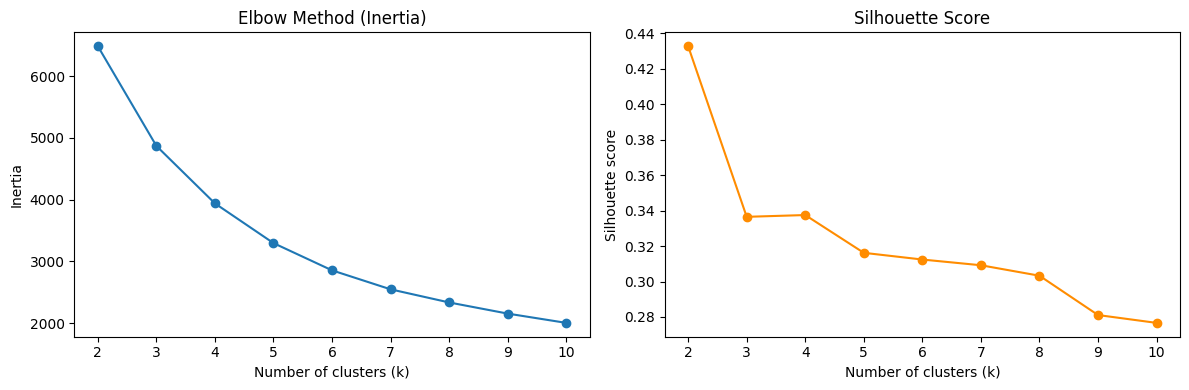

In [32]:
# Plot the Elbow and Silhouette
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(list(K), inertia, 'o-')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of clusters (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(list(K), sil, 'o-', color='darkorange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of clusters (k)')
ax[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.savefig('../outputs/figures/optimal_k.png', dpi=130)
plt.show()

### K-means CLustering

In [33]:
#  Fit K-Means and assign each customer a cluster
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

rfm = pd.read_csv('../data/processed/rfm.csv')          # real values, for reading later
scaled = pd.read_csv('../data/processed/rfm_scaled.csv')  # scaled values, for the model
features = ['Recency', 'Frequency', 'Monetary']
X = scaled[features]

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
scaled['Cluster'] = kmeans.fit_predict(X)

rfm = rfm.merge(scaled[['CustomerID', 'Cluster']], on='CustomerID')
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,3
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


In [34]:
# How many customers in each cluster
rfm['Cluster'].value_counts().sort_index()

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

In [35]:
# Profile each cluster (the key table)
profile = rfm.groupby('Cluster').agg(
    Count=('CustomerID', 'size'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean')
).round(1)
profile

,Count,Recency,Frequency,Monetary
Cluster,,,,
0,713,12.2,13.8,8088.0
1,1622,181.5,1.3,341.0
2,837,17.7,2.2,557.3
3,1166,71.6,4.1,1801.8


In [36]:
# Save the clustered data
rfm.to_csv('../data/processed/rfm_clustered.csv', index=False)
print('Saved rfm_clustered.csv')

Saved rfm_clustered.csv


### PCA VISUALIZATION

In [37]:
 #Load data and fit PCA
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaled = pd.read_csv('../data/processed/rfm_scaled.csv')
clustered = pd.read_csv('../data/processed/rfm_clustered.csv')
scaled = scaled.merge(clustered[['CustomerID', 'Cluster']], on='CustomerID')
features = ['Recency', 'Frequency', 'Monetary']

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(scaled[features])
scaled['PC1'] = coords[:, 0]
scaled['PC2'] = coords[:, 1]

In [38]:
# Check how much information PCA kept
print('PC1:', round(pca.explained_variance_ratio_[0] * 100, 1), '%')
print('PC2:', round(pca.explained_variance_ratio_[1] * 100, 1), '%')
print('Total kept:', round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

PC1: 75.1 %
PC2: 18.8 %
Total kept: 93.9 %


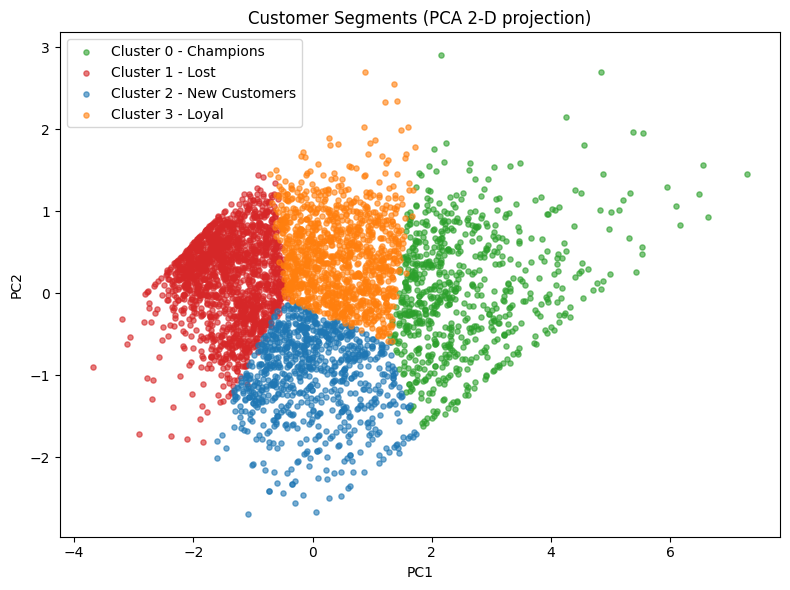

In [39]:
#Plot the segments
plt.figure(figsize=(8, 6))
colors = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e']
names = {0: 'Champions', 1: 'Lost', 2: 'New Customers', 3: 'Loyal'}

for c in sorted(scaled['Cluster'].unique()):
    sub = scaled[scaled['Cluster'] == c]
    plt.scatter(sub['PC1'], sub['PC2'], s=14, alpha=0.6,
                c=colors[c], label=f'Cluster {c} - {names[c]}')

plt.title('Customer Segments (PCA 2-D projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/segments_pca.png', dpi=130)
plt.show()

### cluster interpretation and segment profiling

In [40]:
#Build the enriched profile table
import pandas as pd
import numpy as np

rfm = pd.read_csv('../data/processed/rfm_clustered.csv')
total_rev = rfm['Monetary'].sum()

profile = rfm.groupby('Cluster').agg(
    Count=('CustomerID', 'size'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')
).round(1)

profile['PctCustomers'] = (profile['Count'] / len(rfm) * 100).round(1)
profile['PctRevenue'] = (profile['TotalRevenue'] / total_rev * 100).round(1)
profile

,Count,Recency,Frequency,Monetary,TotalRevenue,PctCustomers,PctRevenue
Cluster,,,,,,,
0,713,12.2,13.8,8088.0,5766757.1,16.4,64.9
1,1622,181.5,1.3,341.0,553099.8,37.4,6.2
2,837,17.7,2.2,557.3,466479.0,19.3,5.2
3,1166,71.6,4.1,1801.8,2100873.0,26.9,23.6


In [41]:
# Name the segments
segment_names = {0: 'Champions', 1: 'Lost', 2: 'New Customers', 3: 'Loyal'}
rfm['Segment'] = rfm['Cluster'].map(segment_names)

profile['Segment'] = profile.index.map(segment_names)
show = profile[['Segment', 'Count', 'PctCustomers', 'Recency', 'Frequency', 'Monetary', 'PctRevenue']]
print(show.to_string(index=False))

      Segment  Count  PctCustomers  Recency  Frequency  Monetary  PctRevenue
    Champions    713          16.4     12.2       13.8    8088.0        64.9
         Lost   1622          37.4    181.5        1.3     341.0         6.2
New Customers    837          19.3     17.7        2.2     557.3         5.2
        Loyal   1166          26.9     71.6        4.1    1801.8        23.6


The killer insight (chart above)
The bar chart compares % of customers vs % of revenue per segment, and it reveals the single most important finding in this entire project:

Champions are only 16% of your customers but generate 65% of revenue. Meanwhile, the "Lost" segment is the largest group (37% of customers) yet contributes just 6% of revenue.

This is the classic Pareto pattern (a small group drives most of the value), and it leads directly to clear business actions:

Champions (16% → 65% revenue): protect at all costs. VIP perks, early access, loyalty rewards. Losing one of these hurts far more than losing a "Lost" customer.
Loyal (27% → 24% revenue): your growth engine. Nudge them toward Champion status with targeted upsells.
New Customers (19% → 5% revenue): high potential. Strong onboarding and a good second-purchase offer to convert them into Loyal.
Lost (37% → 6% revenue): don't overspend here. A light, cheap win-back campaign — but don't pour budget into a low-return group.

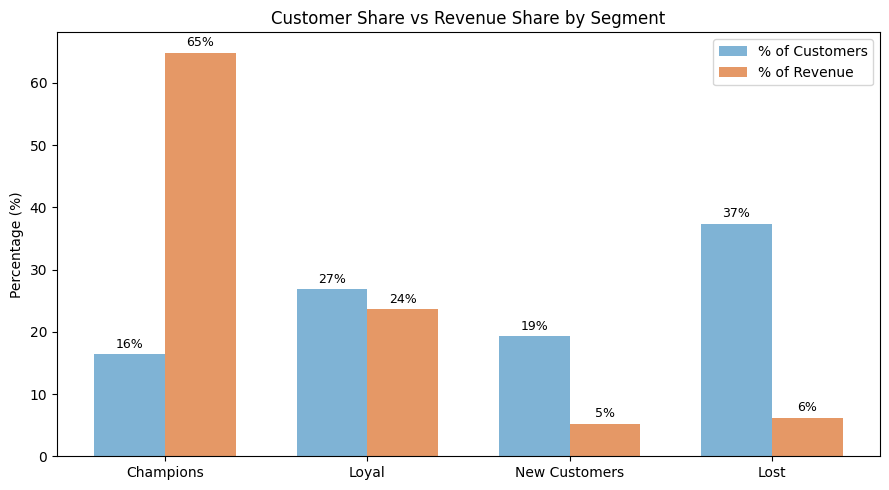

In [45]:
# Cell 3: Visualize Customer Share vs Revenue Share by Segment
import matplotlib.pyplot as plt
import numpy as np

rfm = pd.read_csv('../data/processed/rfm_final.csv')
total_rev = rfm['Monetary'].sum()

g = rfm.groupby('Segment').agg(Count=('CustomerID', 'size'), Rev=('Monetary', 'sum'))
order = ['Champions', 'Loyal', 'New Customers', 'Lost']
g = g.loc[order]
g['PctCust'] = g['Count'] / g['Count'].sum() * 100
g['PctRev'] = g['Rev'] / total_rev * 100

x = np.arange(len(order))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, g['PctCust'], w, label='% of Customers', color='#7fb3d5')
ax.bar(x + w/2, g['PctRev'], w, label='% of Revenue', color='#e59866')
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel('Percentage (%)')
ax.set_title('Customer Share vs Revenue Share by Segment')
for i, (c, r) in enumerate(zip(g['PctCust'], g['PctRev'])):
    ax.text(i - w/2, c + 1, f'{c:.0f}%', ha='center', fontsize=9)
    ax.text(i + w/2, r + 1, f'{r:.0f}%', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/segment_value.png', dpi=130)
plt.show()

In [44]:
#Save the final labeled dataset
rfm.to_csv('../data/processed/rfm_final.csv', index=False)
print('Saved rfm_final.csv')

Saved rfm_final.csv


### Saving the Trained Model

In [1]:
# Save the trained model for the Flask app
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

os.makedirs('../models', exist_ok=True)

rfm = pd.read_csv('../data/processed/rfm.csv')
features = ['Recency', 'Frequency', 'Monetary']

# Rebuild the exact same pipeline we used: log1p -> scale -> KMeans (k=4)
rfm_log = np.log1p(rfm[features].values)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)

segment_map = {0: 'Champions', 1: 'Lost', 2: 'New Customers', 3: 'Loyal'}

joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(kmeans, '../models/kmeans.pkl')
joblib.dump(segment_map, '../models/segment_map.pkl')
print('Saved:', os.listdir('../models'))

F:\Softwares installation\Python Software\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "F:\Softwares installation\Python Software\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "F:\Softwares installation\Python Software\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "F:\Softwares installation\Python Software\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "F:\Softwares installation\Python Software\Lib\

Saved: ['kmeans.pkl', 'scaler.pkl', 'segment_map.pkl']
